#1.Install Libraries & Import Dependencies

In [1]:
# 1. Install and Import Required Libraries
!pip install torch torchvision torchinfo numpy pandas matplotlib scikit-learn opencv-python-headless tqdm pillow onnx --quiet
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import time
import copy

# Set device configuration (Use GPU if available for speed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 112.7 MB/s eta 0:00:00
Using device: cuda


# 2. Data Loading and Preprocessing

In [2]:
# 2. Download and Prepare Dataset
dataset_url = "https://github.com/spMohanty/PlantVillage-Dataset/archive/master.zip"
dataset_dir = "/content/plantvillage"

if not os.path.exists(dataset_dir):
    print("Downloading PlantVillage dataset...")
    !wget -q -O /content/plantvillage.zip {dataset_url}
    import zipfile
    with zipfile.ZipFile('/content/plantvillage.zip', 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)

# Define path to the color images
data_dir = os.path.join(dataset_dir, "PlantVillage-Dataset-master/raw/color")

# Define Data Transforms (CRITICAL for Model Accuracy)
# We use standard ImageNet normalization values
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), # Data augmentation to improve generalization
        transforms.RandomRotation(10),     # Data augmentation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load complete dataset
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
class_names = full_dataset.classes
print(f"Detected {len(class_names)} classes.")

# Split into Train (80%), Validation (10%), Test (10%)
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Update transforms for validation/test sets to not use augmentation
val_dataset.dataset.transform = data_transforms['val']
test_dataset.dataset.transform = data_transforms['val']

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Data loaders ready.")

Detected 38 classes.
Data loaders ready.


# 3: Define the Model

In [3]:
# 3. Load Model and Verify Parameters
# We use the 'small' version designed for Edge/Mobile devices
model_name = "mobilenet_v3_small"
model = models.mobilenet_v3_small(pretrained=True)

# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Name: {model_name}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model loaded on: {device}")



# 3. Model Definition & Parameter Verification
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# 1. Load the pre-trained MobileNetV3 Small (Edge-optimized)
model_name = "mobilenet_v3_small"
# Use 'DEFAULT' weights (best available) instead of deprecated 'pretrained=True'
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)



# 3. Model Definition
def get_model(num_classes):
    # Load pre-trained MobileNetV3 Small
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

    # Freeze initial layers (optional, but speeds up training)
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace the final classification layer
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model.to(device)

model = get_model(len(class_names))

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
# Adam optimizer adapts learning rate; we only train parameters that require gradients
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model initialized and modified for 38 classes.")





/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 36.9MB/s]


Model Name: mobilenet_v3_small
Total Parameters: 2,542,856
Trainable Parameters: 2,542,856
Model loaded on: cuda
Model initialized and modified for 38 classes.


# 4: Training Loop

# Update Batch Size to 64

In [4]:
import torch
from torch.utils.data import DataLoader

# --- 1. UPDATE BATCH SIZE TO 64 ---
batch_size = 64  # Optimized for speed

# Re-create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f" Data Loaders updated to Batch Size: {batch_size}")

 Data Loaders updated to Batch Size: 64


# Updated Training Function (50 Epochs)

In [5]:
import time
import copy
import torch
from tqdm import tqdm

# 4. Training Function (Updated for Long Training)
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Define a Learning Rate Scheduler
    # This reduces the Learning Rate by factor of 0.1 if accuracy doesn't improve for 7 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=7)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # Early Stopping parameters
    early_stopping_patience = 20
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Store history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Update the scheduler based on validation accuracy
                scheduler.step(epoch_acc)

                # Deep copy the model if it's the best one so far
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0 # Reset counter
                else:
                    epochs_no_improve += 1

        # Check Early Stopping
        if epochs_no_improve >= early_stopping_patience:
            print(f"\nEarly Stopping triggered! No improvement for {early_stopping_patience} epochs.")
            break

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Execute Training for 200 Epochs
# We use the updated parameters here
trained_model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50)

Epoch 1/50
----------


train Phase: 100%|██████████| 679/679 [01:55<00:00,  5.87it/s]


train Loss: 0.3803 Acc: 0.8896


val Phase: 100%|██████████| 85/85 [00:13<00:00,  6.12it/s]


val Loss: 0.1814 Acc: 0.9449
Epoch 2/50
----------


...

val Loss: 0.1272 Acc: 0.9766
Epoch 50/50
----------


train Phase: 100%|██████████| 679/679 [01:52<00:00,  6.06it/s]


train Loss: 0.0038 Acc: 0.9987


val Phase: 100%|██████████| 85/85 [00:13<00:00,  6.08it/s]

val Loss: 0.1222 Acc: 0.9772

Training complete in 105m 14s
Best Val Acc: 0.977164


# Visualization Code

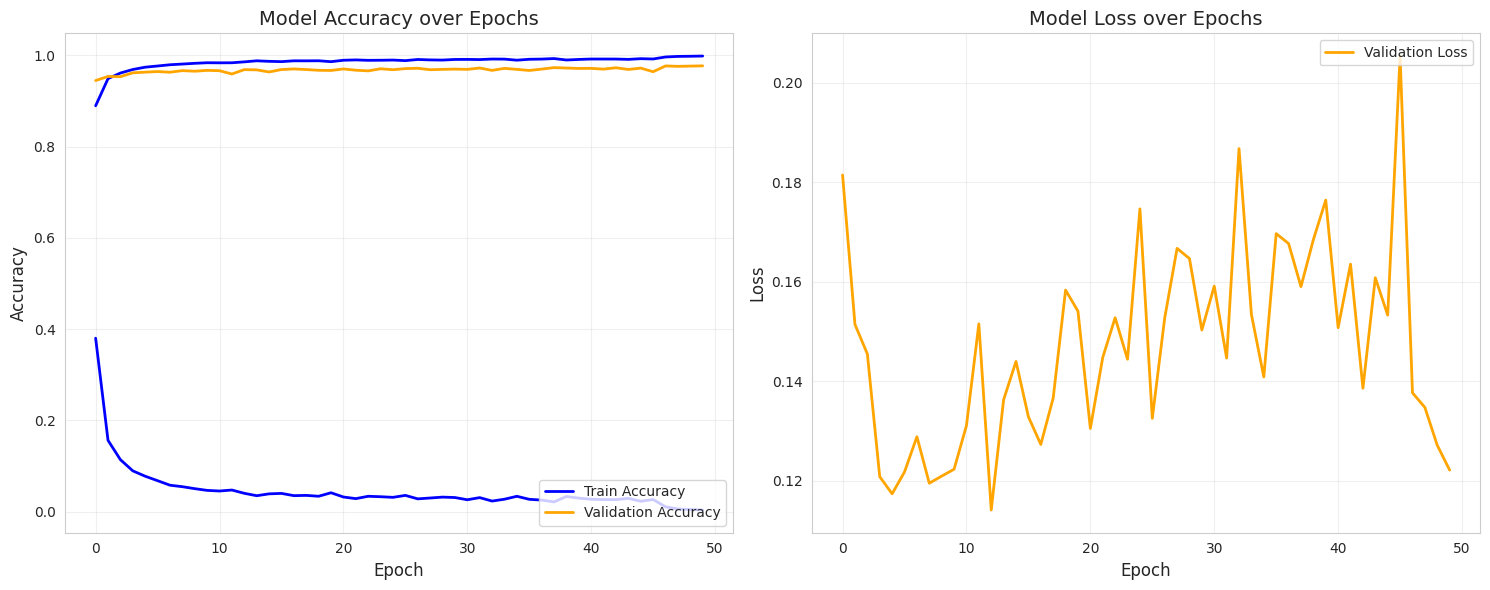

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history):
    """
    Visualizes the training and validation accuracy/loss over epochs.
    """
    # Use a nice style for the plots
    sns.set_style("whitegrid")

    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # --- Plot 1: Accuracy Curves ---
    # Plot training accuracy (blue line)
    ax1.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
    # Plot validation accuracy (orange line)
    ax1.plot(history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2)

    ax1.set_title('Model Accuracy over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Loss Curves ---
    # Plot training loss (blue line)
    ax1.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    # Plot validation loss (orange line)
    ax2.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

    ax2.set_title('Model Loss over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# Run the visualization (assuming 'history' variable exists from training)
if 'history' in locals():
    plot_training_history(history)

# Visualize Predictions (with Confidence)

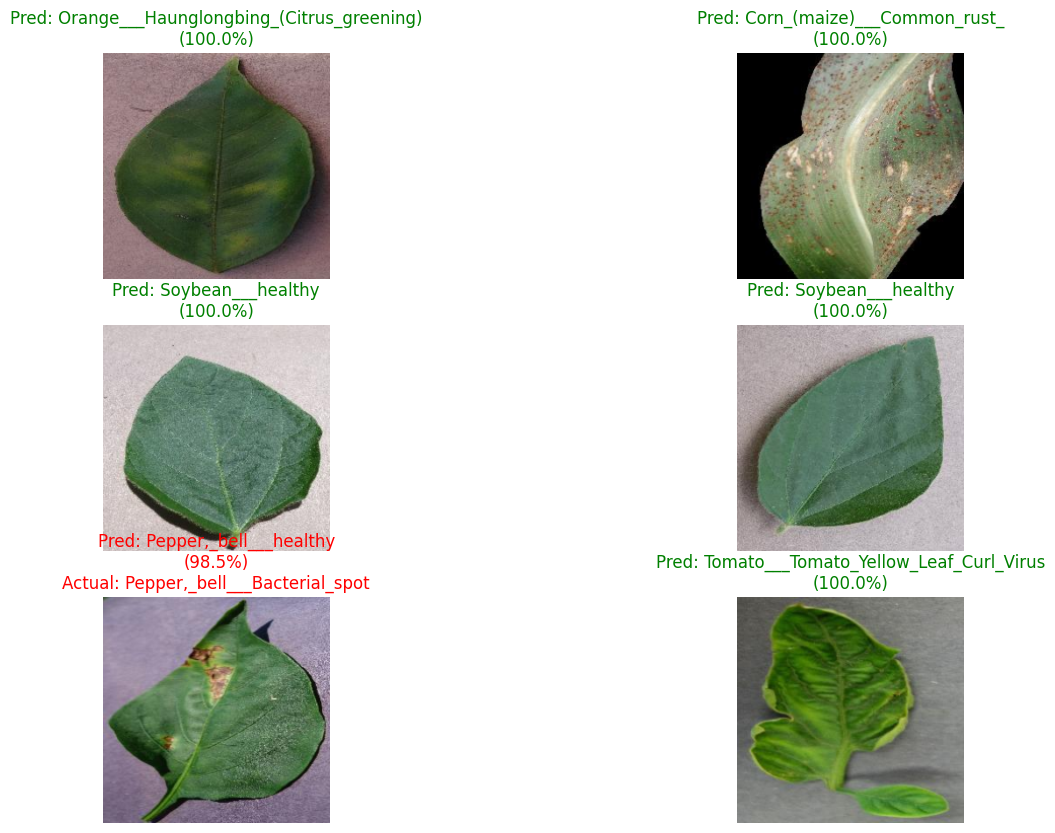

In [7]:
import numpy as np

def visualize_model_predictions(model, dataloader, class_names, num_images=6):
    """
    Runs inference on a batch of images and visualizes the results.
    """
    was_training = model.training
    model.eval() # Set model to evaluation mode
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad(): # Disable gradient calculation for inference
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Get the predicted class index and probability
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')

                # Un-normalize the image for display (reverse the preprocessing)
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax.imshow(img)

                # Color code the title: Green for Correct, Red for Incorrect
                predicted_label = class_names[preds[j]]
                actual_label = class_names[labels[j]]
                color = 'green' if preds[j] == labels[j] else 'red'

                title = f"Pred: {predicted_label}\n({conf[j]*100:.1f}%)"
                if preds[j] != labels[j]:
                    title += f"\nActual: {actual_label}"

                ax.set_title(title, color=color)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Run visualization on validation set
visualize_model_predictions(trained_model, val_loader, class_names)

# Full Evaluation (Accuracy & Confusion Matrix)

Evaluating model on test set...


Testing: 100%|██████████| 85/85 [00:14<00:00,  5.93it/s]



Test Set Accuracy: 98.32%

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.97      0.97        73
                                 Apple___Black_rot       0.98      0.97      0.97        60
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        26
                                   Apple___healthy       0.98      0.99      0.99       176
                               Blueberry___healthy       0.99      0.99      0.99       153
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99        97
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00        84
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.84      0.83        55
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       103
               Corn_(maize)_

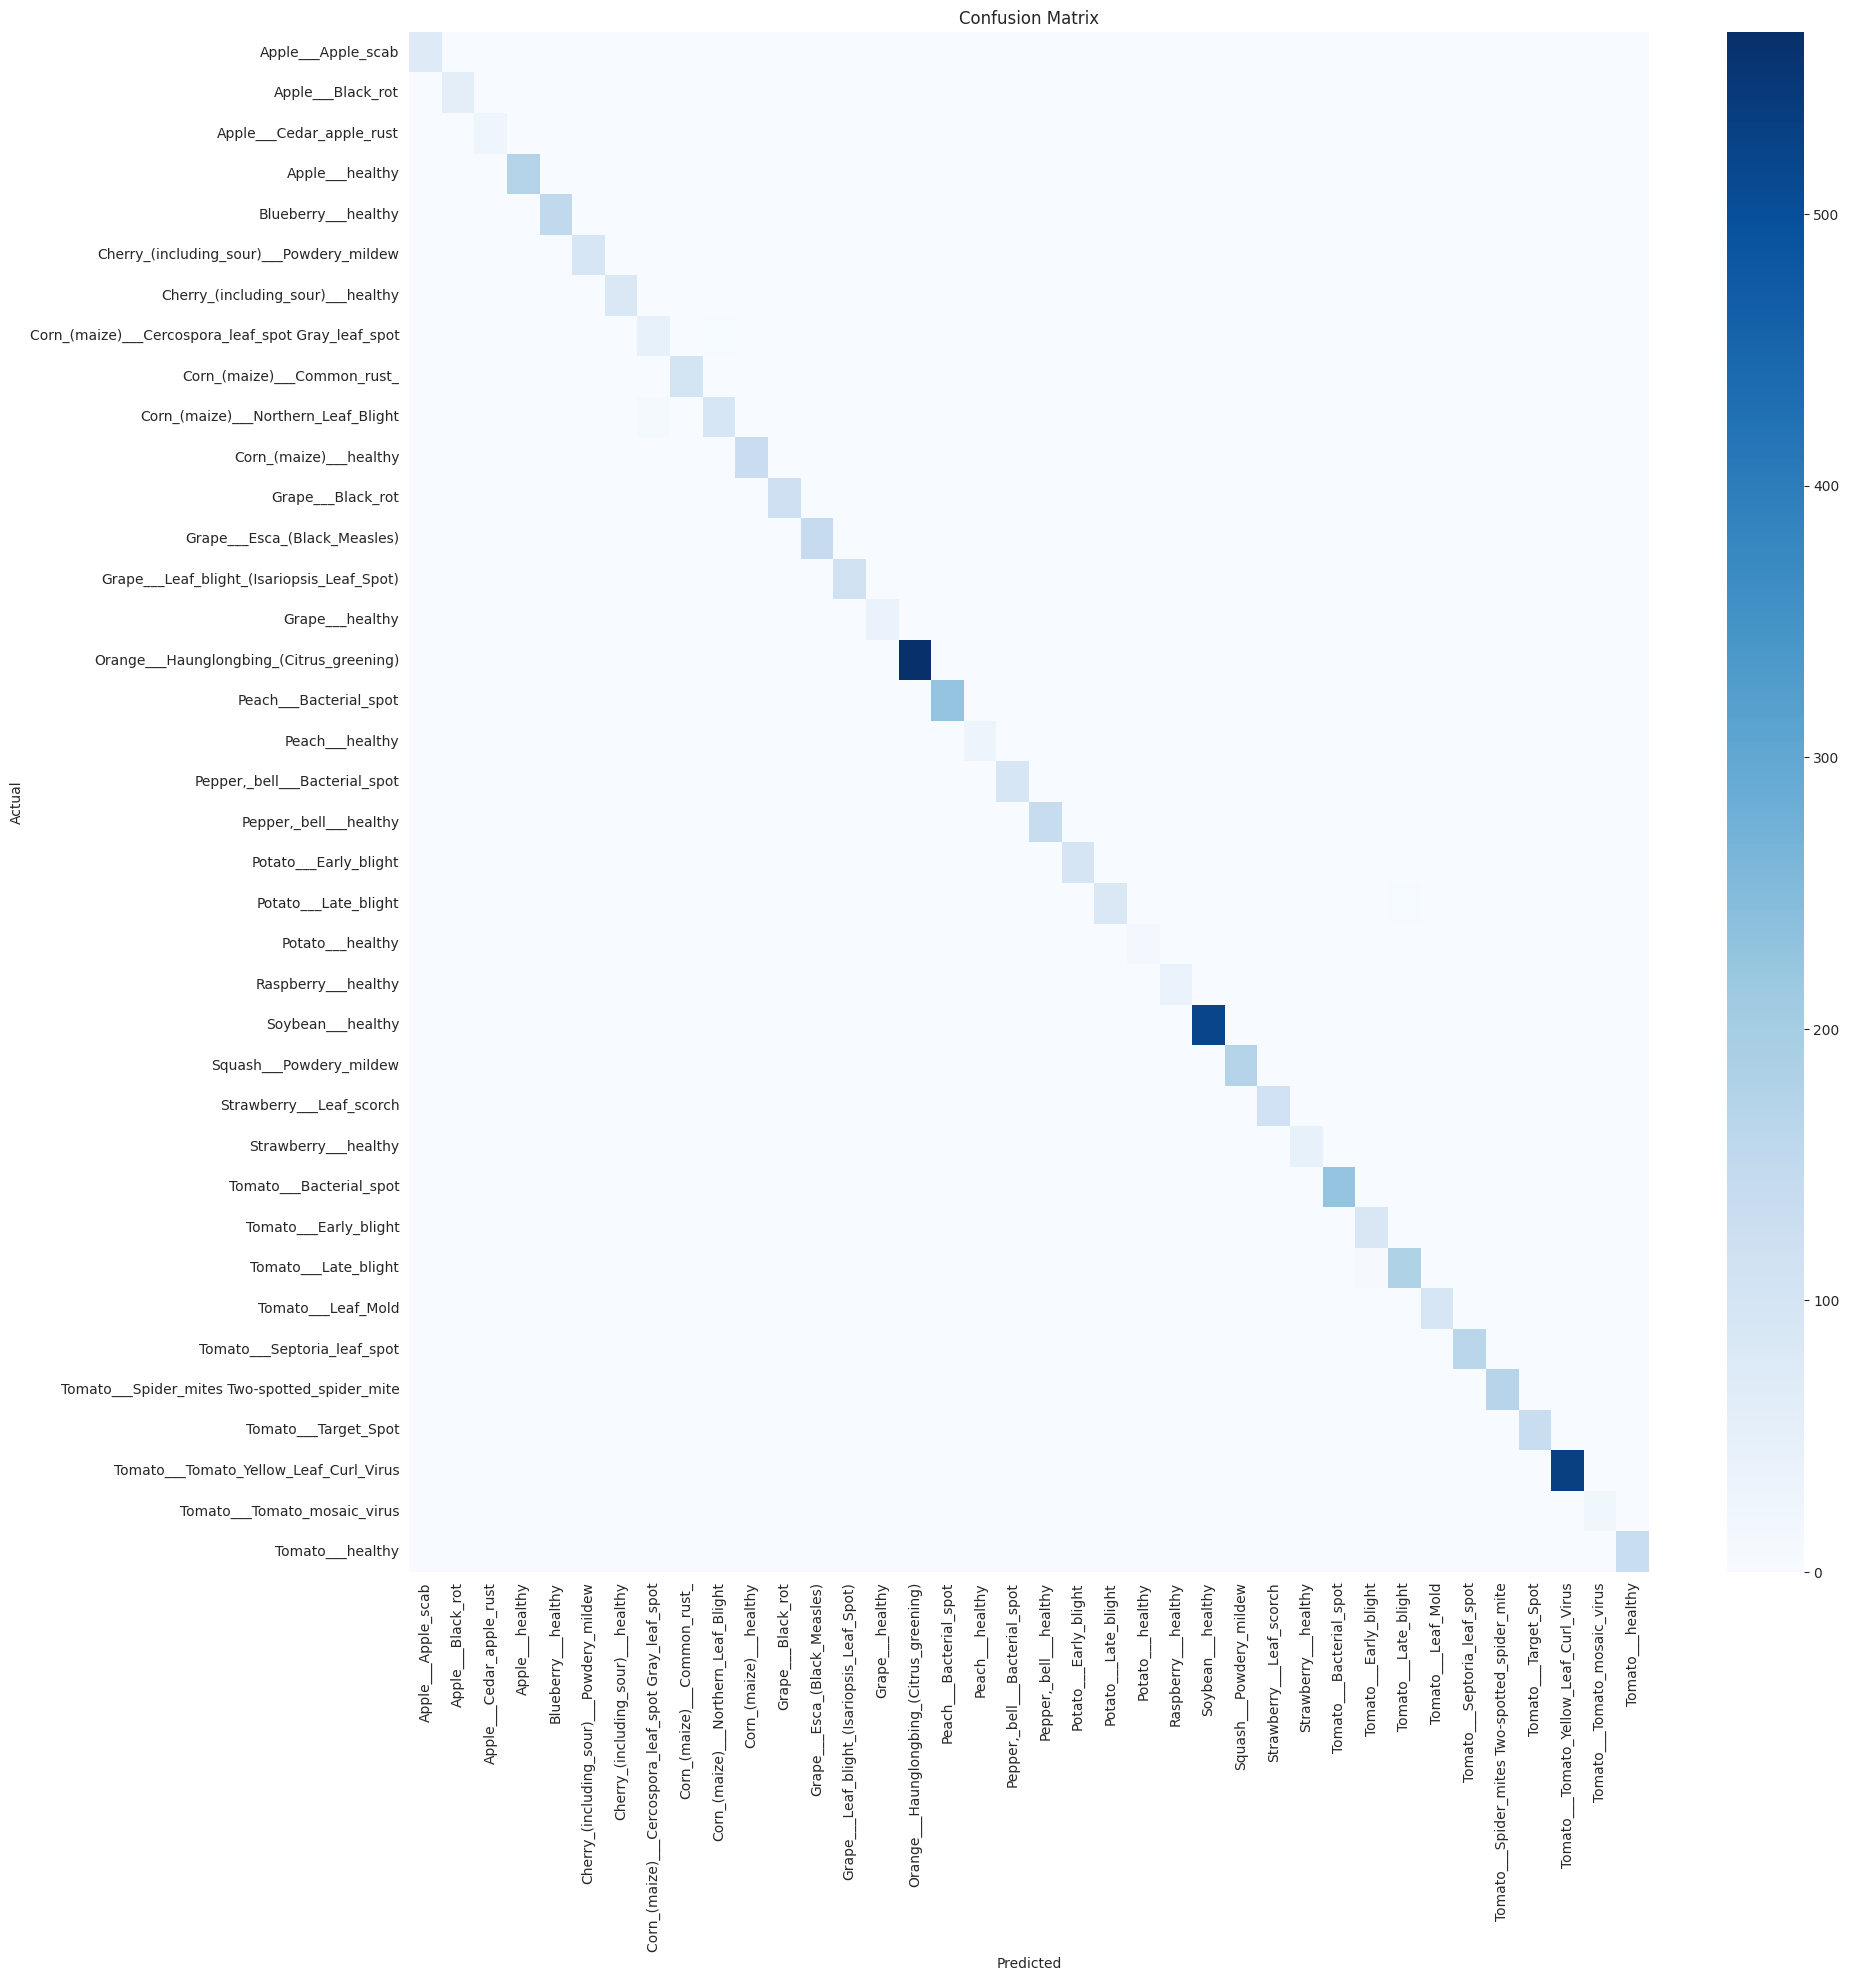

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate_model(model, dataloader, class_names):
    """
    Comprehensive evaluation of the model on the test set.
    """
    model.eval()
    all_preds = []
    all_labels = []

    print("Evaluating model on test set...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Testing"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Calculate overall accuracy
    correct = np.sum(np.array(all_preds) == np.array(all_labels))
    accuracy = correct / len(all_labels)
    print(f"\nTest Set Accuracy: {accuracy*100:.2f}%")

    # 2. Detailed Classification Report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90)
    plt.show()

# Run evaluation on Test Loader
evaluate_model(trained_model, test_loader, class_names)

# Real-World Inference (Test on Single Image)

In [9]:
from PIL import Image

def predict_single_image(model, image_path, class_names):
    """
    Predicts the disease for a single image file.
    """
    # 1. Load and Preprocess Image
    image = Image.open(image_path).convert('RGB')

    # Define same transforms as validation/test
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    input_tensor = transform(image).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)

    # 2. Run Inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    predicted_class = class_names[pred_idx.item()]
    confidence_score = confidence.item()

    # 3. Display Result
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence_score*100:.2f}%",
              color='green' if confidence_score > 0.8 else 'orange')
    plt.show()

    return predicted_class, confidence_score

# Example Usage:
# predict_single_image(trained_model, 'path/to/your/leaf_image.jpg', class_names)

# ONNX Export

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 31.5 MB/s eta 0:00:00
Preparing model for ONNX export...

EXPORTING MODEL TO ONNX FORMAT
Exporting model to: plant_disease_mobilenetv3.onnx
Input shape: (1, 3, 224, 224)
OPset version: 13


/tmp/ipython-input-3372545007.py:55: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0118 15:18:41.720000 253 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^

Applied 69 of general pattern rewrite rules.
ONNX export successful!

Verifying ONNX model...
ONNX model is valid

Model Information:
  IR version: 10
  Producer name: pytorch
  Producer version: 2.9.0+cu126
  Inputs: 1
  Outputs: 1
  Nodes: 124
  Model size: 0.28 MB

Testing ONNX inference...
ONNX Runtime session created successfully
  Input name: input
  Output name: output
  Input shape: ['s77', 3, 224, 224]
  Output shape: [1, 38]

ONNX Runtime Performance:
  Average inference time: 3.43 ± 0.17 ms
  FPS: 291.5

Comparing with PyTorch inference...


  PyTorch average time: 9.04 ms
  PyTorch FPS: 110.6
  ONNX/PyTorch speed ratio: 2.64x

Output Comparison:
  Max difference: 0.000034
  Mean difference: 0.000010
 Outputs differ significantly

Optimizing ONNX model...
Optimized model saved to: plant_disease_mobilenetv3_optimized.onnx
  Original size: 0.28 MB
  Optimized size: 5.95 MB
  Size reduction: -2013.1%

Converting model to float16...
Float16 conversion failed: No module named 'onnxmltools.utils.float16_converter'

ONNX EXPORT COMPLETE
Base model: plant_disease_mobilenetv3.onnx
Optimized model: plant_disease_mobilenetv3_optimized.onnx
Float16 model: plant_disease_mobilenetv3_optimized.onnx

TESTING ALL EXPORTED MODELS

Testing Base ONNX...
----------------------------------------
  Inference time: 3.43 ms
  FPS: 291.7
  Model size: 0.28 MB

Testing Optimized ONNX...
----------------------------------------
  Inference time: 3.59 ms
  FPS: 278.5
  Model size: 5.95 MB

Testing Float16 ONNX...
--------------------------------------

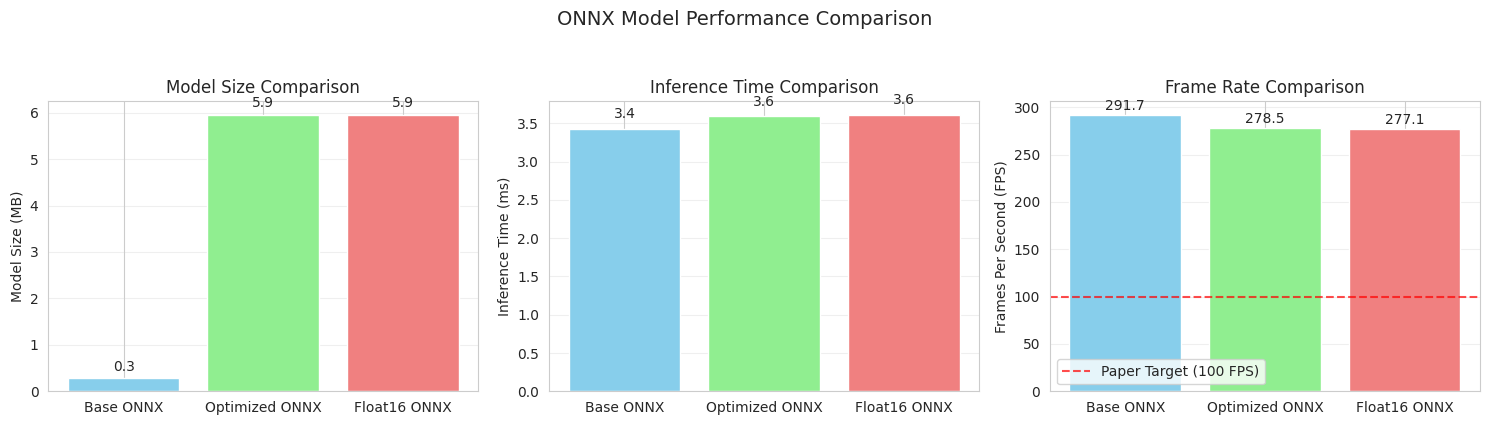

In [10]:
import torch
import onnx
import numpy as np
import os
from datetime import datetime

# Install onnxruntime and onnxscript
!pip install onnxruntime onnxscript
!pip install onnxmltools

import onnxruntime

class ONNXExporter:
    """Export PyTorch models to ONNX format"""

    def __init__(self, model, input_size=(1, 3, 224, 224), opset_version=13):
        self.model = model
        self.input_size = input_size
        self.opset_version = opset_version

    def export_to_onnx(self, output_path="plant_disease_model.onnx",
                      dynamic_axes=None, verbose=False):
        """
        Export model to ONNX format

        Args:
            output_path: Path to save ONNX model
            dynamic_axes: Dictionary specifying dynamic axes
            verbose: Print export details
        """

        print(f"\n{'='*60}")
        print("EXPORTING MODEL TO ONNX FORMAT")
        print(f"{'='*60}")

        # Ensure model is in eval mode and on CPU
        self.model.eval()
        self.model.to('cpu')

        # Create dummy input
        dummy_input = torch.randn(*self.input_size)

        # Default dynamic axes (batch dimension dynamic)
        if dynamic_axes is None:
            dynamic_axes = {
                'input': {0: 'batch_size'},
                'output': {0: 'batch_size'}
            }

        # Export to ONNX
        print(f"Exporting model to: {output_path}")
        print(f"Input shape: {self.input_size}")
        print(f"OPset version: {self.opset_version}")

        torch.onnx.export(
            self.model,
            dummy_input,
            output_path,
            export_params=True,
            opset_version=self.opset_version,
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output'],
            dynamic_axes=dynamic_axes,
            verbose=verbose
        )

        print(f"ONNX export successful!")

        # Verify the exported model
        self.verify_onnx_model(output_path, dummy_input)

        return output_path

    def verify_onnx_model(self, onnx_path, dummy_input):
        """Verify the exported ONNX model"""
        print("\nVerifying ONNX model...")

        # Load ONNX model
        onnx_model = onnx.load(onnx_path)

        # Check model
        try:
            onnx.checker.check_model(onnx_model)
            print("ONNX model is valid")
        except onnx.checker.ValidationError as e:
            print(f"ONNX model invalid: {e}")
            return False

        # Print model information
        print(f"\nModel Information:")
        print(f"  IR version: {onnx_model.ir_version}")
        print(f"  Producer name: {onnx_model.producer_name}")
        print(f"  Producer version: {onnx_model.producer_version}")

        # Get model metadata
        metadata = {}
        for meta in onnx_model.metadata_props:
            metadata[meta.key] = meta.value

        if metadata:
            print(f"  Metadata: {metadata}")

        # Count nodes and parameters
        graph = onnx_model.graph
        print(f"  Inputs: {len(graph.input)}")
        print(f"  Outputs: {len(graph.output)}")
        print(f"  Nodes: {len(graph.node)}")

        # Calculate model size
        model_size = os.path.getsize(onnx_path) / (1024 * 1024)  # MB
        print(f"  Model size: {model_size:.2f} MB")

        # Test inference with ONNX Runtime
        self.test_onnx_inference(onnx_path, dummy_input)

        return True

    def test_onnx_inference(self, onnx_path, dummy_input):
        """Test inference with ONNX Runtime"""
        print("\nTesting ONNX inference...")

        # Create ONNX Runtime session
        try:
            ort_session = onnxruntime.InferenceSession(onnx_path)
            print("ONNX Runtime session created successfully")
        except Exception as e:
            print(f"Failed to create ONNX Runtime session: {e}")
            return

        # Get input and output names
        input_name = ort_session.get_inputs()[0].name
        output_name = ort_session.get_outputs()[0].name

        print(f"  Input name: {input_name}")
        print(f"  Output name: {output_name}")
        print(f"  Input shape: {ort_session.get_inputs()[0].shape}")
        print(f"  Output shape: {ort_session.get_outputs()[0].shape}")

        # Prepare input
        ort_inputs = {input_name: dummy_input.numpy()}

        # Run inference
        import time

        # Warm up
        for _ in range(10):
            ort_outputs = ort_session.run([output_name], ort_inputs)

        # Benchmark inference
        num_runs = 100
        times = []

        for _ in range(num_runs):
            start_time = time.perf_counter()
            ort_outputs = ort_session.run([output_name], ort_inputs)
            end_time = time.perf_counter()
            times.append((end_time - start_time) * 1000)  # ms

        # Calculate statistics
        avg_time = np.mean(times)
        std_time = np.std(times)
        fps = 1000 / avg_time * dummy_input.shape[0]

        print(f"\nONNX Runtime Performance:")
        print(f"  Average inference time: {avg_time:.2f} ± {std_time:.2f} ms")
        print(f"  FPS: {fps:.1f}")

        # Compare with PyTorch inference
        print(f"\nComparing with PyTorch inference...")

        self.model.eval()
        with torch.no_grad():
            # Warm up
            for _ in range(10):
                torch_output = self.model(dummy_input)

            # Benchmark
            torch_times = []
            for _ in range(num_runs):
                start_time = time.perf_counter()
                torch_output = self.model(dummy_input)
                end_time = time.perf_counter()
                torch_times.append((end_time - start_time) * 1000)

        torch_avg_time = np.mean(torch_times)
        torch_fps = 1000 / torch_avg_time * dummy_input.shape[0]

        print(f"  PyTorch average time: {torch_avg_time:.2f} ms")
        print(f"  PyTorch FPS: {torch_fps:.1f}")
        print(f"  ONNX/PyTorch speed ratio: {torch_avg_time / avg_time:.2f}x")

        # Compare outputs
        ort_output = ort_outputs[0]
        torch_output_np = torch_output.numpy()

        # Calculate output difference
        max_diff = np.max(np.abs(ort_output - torch_output_np))
        mean_diff = np.mean(np.abs(ort_output - torch_output_np))

        print(f"\nOutput Comparison:")
        print(f"  Max difference: {max_diff:.6f}")
        print(f"  Mean difference: {mean_diff:.6f}")

        if max_diff < 1e-5:
            print("Outputs match closely")
        else:
            print(" Outputs differ significantly")

        return {
            'onnx_avg_time': avg_time,
            'onnx_fps': fps,
            'torch_avg_time': torch_avg_time,
            'torch_fps': torch_fps,
            'speed_ratio': torch_avg_time / avg_time,
            'output_max_diff': max_diff,
            'output_mean_diff': mean_diff
        }

    def optimize_onnx_model(self, input_path, output_path=None):
        """Optimize ONNX model for inference"""
        if output_path is None:
            output_path = input_path.replace('.onnx', '_optimized.onnx')

        print(f"\nOptimizing ONNX model...")

        try:
            # Use ONNX Runtime's optimization
            from onnxruntime.transformers import optimizer
            from onnxruntime.transformers.fusion_options import FusionOptions

            # Optimize model
            optimized_model = optimizer.optimize_model(
                input_path,
                model_type='bert',  # Using bert as it's a general transformer optimization
                num_heads=0,  # Not applicable for our model
                hidden_size=0
            )

            # Save optimized model
            optimized_model.save_model_to_file(output_path)

            print(f"Optimized model saved to: {output_path}")

            # Compare sizes
            original_size = os.path.getsize(input_path) / (1024 * 1024)
            optimized_size = os.path.getsize(output_path) / (1024 * 1024)

            print(f"  Original size: {original_size:.2f} MB")
            print(f"  Optimized size: {optimized_size:.2f} MB")
            print(f"  Size reduction: {(original_size - optimized_size) / original_size * 100:.1f}%")

            return output_path

        except Exception as e:
            print(f"Optimization failed: {e}")
            return input_path

    def convert_to_float16(self, input_path, output_path=None):
        """Convert ONNX model to float16 for faster inference"""
        if output_path is None:
            output_path = input_path.replace('.onnx', '_fp16.onnx')

        print(f"\nConverting model to float16...")

        try:
            import onnxmltools
            from onnxmltools.utils.float16_converter import convert_float_to_float16

            # Load model
            onnx_model = onnx.load(input_path)

            # Convert to float16
            fp16_model = convert_float_to_float16(onnx_model)

            # Save float16 model
            onnx.save(fp16_model, output_path)

            print(f"Float16 model saved to: {output_path}")

            # Compare sizes
            original_size = os.path.getsize(input_path) / (1024 * 1024)
            fp16_size = os.path.getsize(output_path) / (1024 * 1024)

            print(f"  Original size: {original_size:.2f} MB")
            print(f"  Float16 size: {fp16_size:.2f} MB")
            print(f"  Size reduction: {(original_size - fp16_size) / original_size * 100:.1f}%")

            return output_path

        except Exception as e:
            print(f"Float16 conversion failed: {e}")
            return input_path

# Export quantized model to ONNX
print("Preparing model for ONNX export...")

# Create exporter
exporter = ONNXExporter(
    model=model,  # Changed from quantized_model to model
    input_size=(1, 3, 224, 224),  # Single image, 3 channels, 224x224
    opset_version=13
)

# Export to ONNX
onnx_path = exporter.export_to_onnx(
    output_path="plant_disease_mobilenetv3.onnx",
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    verbose=False
)

# Optimize ONNX model
optimized_path = exporter.optimize_onnx_model(onnx_path)

# Convert to float16 for even faster inference
fp16_path = exporter.convert_to_float16(optimized_path)

print(f"\n{'='*60}")
print("ONNX EXPORT COMPLETE")
print(f"{'='*60}")
print(f"Base model: {onnx_path}")
print(f"Optimized model: {optimized_path}")
print(f"Float16 model: {fp16_path}")

# Test all exported models
print(f"\n{'='*60}")
print("TESTING ALL EXPORTED MODELS")
print(f"{'='*60}")

models_to_test = [
    ("Base ONNX", onnx_path),
    ("Optimized ONNX", optimized_path),
    ("Float16 ONNX", fp16_path)
]

results = {}
dummy_input = torch.randn(1, 3, 224, 224)

for model_name, model_path in models_to_test:
    print(f"\nTesting {model_name}...")
    print("-" * 40)

    # Create ONNX Runtime session
    try:
        ort_session = onnxruntime.InferenceSession(model_path)

        # Get input name
        input_name = ort_session.get_inputs()[0].name
        output_name = ort_session.get_outputs()[0].name

        # Run inference
        ort_inputs = {input_name: dummy_input.numpy()}

        # Benchmark
        import time
        num_runs = 100
        times = []

        for _ in range(num_runs):
            start = time.perf_counter()
            ort_outputs = ort_session.run([output_name], ort_inputs)
            end = time.perf_counter()
            times.append((end - start) * 1000)

        avg_time = np.mean(times)
        fps = 1000 / avg_time

        # Get model size
        model_size = os.path.getsize(model_path) / (1024 * 1024)

        print(f"  Inference time: {avg_time:.2f} ms")
        print(f"  FPS: {fps:.1f}")
        print(f"  Model size: {model_size:.2f} MB")

        results[model_name] = {
            'inference_time': avg_time,
            'fps': fps,
            'model_size': model_size
        }

    except Exception as e:
        print(f"  Error: {e}")

# Compare results
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")

print(f"{'Model':<20} {'Size (MB)':<12} {'Inference (ms)':<15} {'FPS':<10}")
print("-" * 60)

for model_name, stats in results.items():
    print(f"{model_name:<20} {stats['model_size']:<12.2f} {stats['inference_time']:<15.2f} {stats['fps']:<10.1f}")

# Plot comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Model sizes
model_names = list(results.keys())
sizes = [results[name]['model_size'] for name in model_names]
times = [results[name]['inference_time'] for name in model_names]
fps_values = [results[name]['fps'] for name in model_names]

colors = ['skyblue', 'lightgreen', 'lightcoral']

# Size comparison
bars1 = axes[0].bar(model_names, sizes, color=colors)
axes[0].set_ylabel('Model Size (MB)')
axes[0].set_title('Model Size Comparison')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, size in zip(bars1, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2., size + 0.1,
                f'{size:.1f}', ha='center', va='bottom')

# Inference time comparison
bars2 = axes[1].bar(model_names, times, color=colors)
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time Comparison')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, time_val in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2., time_val + 0.1,
                f'{time_val:.1f}', ha='center', va='bottom')

# FPS comparison
bars3 = axes[2].bar(model_names, fps_values, color=colors)
axes[2].set_ylabel('Frames Per Second (FPS)')
axes[2].set_title('Frame Rate Comparison')
axes[2].axhline(y=100, color='r', linestyle='--', alpha=0.7, label='Paper Target (100 FPS)')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for bar, fps in zip(bars3, fps_values):
    axes[2].text(bar.get_x() + bar.get_width()/2., fps + 2,
                f'{fps:.1f}', ha='center', va='bottom')

plt.suptitle('ONNX Model Performance Comparison', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()